# MediaPipe Holistic (Tasks API) — Reference Notebook

The legacy `mediapipe.solutions.holistic` API is **deprecated**. The replacement is to run the three Tasks-API landmarkers side-by-side on the same frame:

| Landmarker | Points | Extra outputs |
| ---------- | ------ | ------------- |
| **Face Landmarker** | 478 (refined eyes + lips) | optional 52 blendshapes + face transform matrix |
| **Pose Landmarker** | 33 | per-point `visibility` and `presence`, optional segmentation mask |
| **Hand Landmarker** | 21 × up to 2 hands | handedness (Left/Right) + world-space landmarks |

This notebook mirrors the structure of [`mediapipe_reference.ipynb`](mediapipe_reference.ipynb) (single image) and [`mediapipe_video_reference.ipynb`](mediapipe_video_reference.ipynb) (VIDEO mode), but exercises all three landmarkers together so we can plan the combined feature vector for the next-gen LSM model.

**References:**
- [Tasks API overview](https://ai.google.dev/edge/mediapipe/solutions/guide)
- [Face Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker/python)
- [Pose Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker/python)
- [Hand Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python)
- [Holistic deprecation notice](https://ai.google.dev/edge/mediapipe/solutions/vision/holistic_landmarker) (legacy → Tasks API migration)

## 1. Imports

In [1]:
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

## 2. Download the model assets

Only `hand_landmarker.task` is currently in `models/`. Grab the other two:

```bash
curl -o models/face_landmarker.task \
  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

curl -o models/pose_landmarker.task \
  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task
```

There are three pose-model variants — `lite` (lightest, mobile), `full` (balanced, what we use here), and `heavy` (most accurate, slowest). Swap the URL if you want a different one.

In [2]:
FACE_MODEL_PATH = "../models/face_landmarker.task"
POSE_MODEL_PATH = "../models/pose_landmarker.task"
HAND_MODEL_PATH = "../models/hand_landmarker.task"

import os
for p in [FACE_MODEL_PATH, POSE_MODEL_PATH, HAND_MODEL_PATH]:
    status = "OK" if os.path.exists(p) else "MISSING — download with the curl commands above"
    print(f"{p}: {status}")

../models/face_landmarker.task: OK
../models/pose_landmarker.task: OK
../models/hand_landmarker.task: OK


## 3. Configure the three landmarkers (IMAGE mode)

Each Tasks-API landmarker has its own `*LandmarkerOptions`. We start in IMAGE mode for a single-frame walkthrough, then re-create them in VIDEO mode further down.

In [3]:
# Face — enable blendshapes and the face-transformation matrix for the full output set
face_options = vision.FaceLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=FACE_MODEL_PATH),
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1,
)

# Pose — single person; segmentation masks off to keep the output light
pose_options = vision.PoseLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=POSE_MODEL_PATH),
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False,
)

# Hands — allow up to two so we capture both signing hands
hand_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=HAND_MODEL_PATH),
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

print("All three landmarkers configured (IMAGE mode).")

All three landmarkers configured (IMAGE mode).


## 4. Grab a single frame from a reference video

Pick any video that shows the upper body — face, torso, and at least one hand. Change `VIDEO_PATH` if you'd rather use `complete.mp4` or `spelling.mov`.

Video: new.mp4
Resolution: 1024x576 @ 30.01 fps (781 frames)
Selected frame: 390


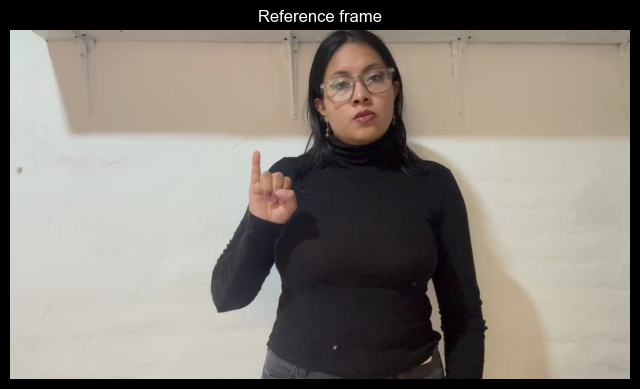

In [4]:
VIDEO_PATH = "new.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Pull the middle frame as a representative still
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame_bgr = cap.read()
cap.release()
assert ret, f"Could not read frame from {VIDEO_PATH}"

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

print(f"Video: {VIDEO_PATH}")
print(f"Resolution: {width}x{height} @ {fps:.2f} fps ({total_frames} frames)")
print(f"Selected frame: {total_frames // 2}")

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Reference frame")
plt.show()

## 5. Face Landmarker — 478 points + blendshapes

Each landmark is a `NormalizedLandmark` with `(x, y, z)` in **image-normalized space** (0-1 over width/height; `z` is roughly depth relative to the face center). Blendshapes are a 52-vector of facial-action coefficients in 0-1 (e.g. `eyeBlinkLeft`, `mouthSmileRight`) — useful for expression-aware models.

In [5]:
with vision.FaceLandmarker.create_from_options(face_options) as landmarker:
    face_result = landmarker.detect(mp_image)

if face_result.face_landmarks:
    face_lms = face_result.face_landmarks[0]
    print(f"Faces detected: {len(face_result.face_landmarks)}")
    print(f"Landmarks per face: {len(face_lms)}")
    print(f"First 3 points:")
    for i, lm in enumerate(face_lms[:3]):
        print(f"  [{i}] x={lm.x:.4f} y={lm.y:.4f} z={lm.z:.4f}")

    blendshapes = face_result.face_blendshapes[0]
    print(f"\nBlendshapes: {len(blendshapes)}")
    top_active = sorted(blendshapes, key=lambda b: b.score, reverse=True)[:8]
    print("Top-8 active blendshapes:")
    for b in top_active:
        print(f"  {b.category_name:30s} {b.score:.3f}")

    tm = np.array(face_result.facial_transformation_matrixes[0])
    print(f"\nFacial transformation matrix shape: {tm.shape}")
else:
    print("No face detected")

I0000 00:00:1780547013.602062 5151725 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 15, prefix = pthread-default
W0000 00:00:1780547013.605114 5151725 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1780547013.676037 5151725 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780547013.681000 5151728 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780547013.688532 5151728 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Faces detected: 1
Landmarks per face: 478
First 3 points:
  [0] x=0.5709 y=0.2301 z=-0.0189
  [1] x=0.5672 y=0.1941 z=-0.0267
  [2] x=0.5683 y=0.2088 z=-0.0159

Blendshapes: 52
Top-8 active blendshapes:
  mouthPucker                    0.511
  browOuterUpLeft                0.459
  eyeLookDownRight               0.350
  eyeLookDownLeft                0.348
  eyeSquintLeft                  0.156
  browOuterUpRight               0.136
  eyeLookOutLeft                 0.115
  eyeLookInRight                 0.101

Facial transformation matrix shape: (4, 4)


## 6. Pose Landmarker — 33 points with visibility & presence

Pose landmarks are the only ones that carry `visibility` (is the joint occluded?) and `presence` (does it exist in the frame at all?). For sign language you'll mostly care about points 0-22 (head, shoulders, elbows, wrists, hips); legs (23-32) are usually off-screen.

In [6]:
POSE_LANDMARK_NAMES = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER",
    "LEFT_EAR", "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT",
    "LEFT_SHOULDER", "RIGHT_SHOULDER",
    "LEFT_ELBOW", "RIGHT_ELBOW",
    "LEFT_WRIST", "RIGHT_WRIST",
    "LEFT_PINKY", "RIGHT_PINKY",
    "LEFT_INDEX", "RIGHT_INDEX",
    "LEFT_THUMB", "RIGHT_THUMB",
    "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE",
    "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL",
    "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]

with vision.PoseLandmarker.create_from_options(pose_options) as landmarker:
    pose_result = landmarker.detect(mp_image)

if pose_result.pose_landmarks:
    pose_lms = pose_result.pose_landmarks[0]
    print(f"Pose landmarks: {len(pose_lms)}")
    print(f"\nUpper-body points (the ones LSM cares about):")
    for i in range(23):
        lm = pose_lms[i]
        print(
            f"  [{i:2d}] {POSE_LANDMARK_NAMES[i]:18s} "
            f"x={lm.x:.3f} y={lm.y:.3f} z={lm.z:+.3f} "
            f"vis={lm.visibility:.2f} pres={lm.presence:.2f}"
        )
else:
    print("No pose detected")

I0000 00:00:1780547014.163610 5151761 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1780547014.196926 5151768 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780547014.203806 5151768 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780547014.221784 5151776 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Pose landmarks: 33

Upper-body points (the ones LSM cares about):
  [ 0] NOSE               x=0.564 y=0.179 z=-0.619 vis=1.00 pres=1.00
  [ 1] LEFT_EYE_INNER     x=0.579 y=0.139 z=-0.591 vis=1.00 pres=1.00
  [ 2] LEFT_EYE           x=0.588 y=0.138 z=-0.591 vis=1.00 pres=1.00
  [ 3] LEFT_EYE_OUTER     x=0.596 y=0.137 z=-0.591 vis=1.00 pres=1.00
  [ 4] RIGHT_EYE_INNER    x=0.545 y=0.145 z=-0.584 vis=1.00 pres=1.00
  [ 5] RIGHT_EYE          x=0.534 y=0.147 z=-0.584 vis=1.00 pres=1.00
  [ 6] RIGHT_EYE_OUTER    x=0.526 y=0.151 z=-0.584 vis=1.00 pres=1.00
  [ 7] LEFT_EAR           x=0.609 y=0.163 z=-0.363 vis=1.00 pres=1.00
  [ 8] RIGHT_EAR          x=0.515 y=0.181 z=-0.324 vis=1.00 pres=1.00
  [ 9] MOUTH_LEFT         x=0.587 y=0.226 z=-0.534 vis=1.00 pres=1.00
  [10] MOUTH_RIGHT        x=0.544 y=0.233 z=-0.524 vis=1.00 pres=1.00
  [11] LEFT_SHOULDER      x=0.690 y=0.441 z=-0.226 vis=1.00 pres=1.00
  [12] RIGHT_SHOULDER     x=0.453 y=0.428 z=-0.196 vis=1.00 pres=1.00
  [13] LEFT_ELBOW       

## 7. Hand Landmarker — 21 × up-to-2 hands

Same format as the existing image-reference notebook, but with `num_hands=2`. The `handedness` field tells you which hand is which (note: MediaPipe assumes a non-mirrored selfie view — Left/Right labels may need to be flipped depending on your capture setup).

In [7]:
with vision.HandLandmarker.create_from_options(hand_options) as landmarker:
    hand_result = landmarker.detect(mp_image)

n_hands = len(hand_result.hand_landmarks) if hand_result.hand_landmarks else 0
print(f"Hands detected: {n_hands}")
for i in range(n_hands):
    handedness = hand_result.handedness[i][0]
    n_lms = len(hand_result.hand_landmarks[i])
    print(f"  Hand {i}: {handedness.display_name} (score={handedness.score:.3f}), {n_lms} landmarks")

I0000 00:00:1780547014.513777 5151860 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1780547014.518500 5151865 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780547014.526327 5151865 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Hands detected: 1
  Hand 0: Right (score=0.997), 21 landmarks


## 8. Combined visualization

Overlay all three landmark sets on the reference frame. Face is drawn as a dense point cloud (no connections — 478 points would make the connection mesh unreadable at this scale), pose as a skeleton, hands with their standard topology.

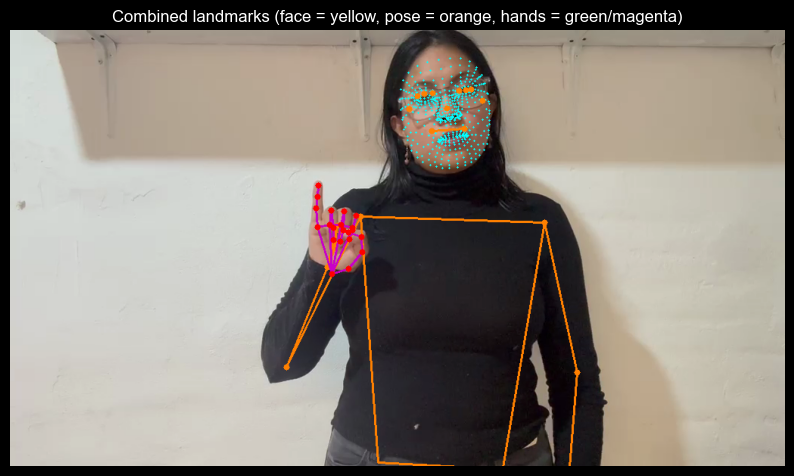

In [8]:
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]

# Subset of the official 35-edge pose topology — the upper-body part we care about
POSE_CONNECTIONS = [
    (11,12),(11,13),(13,15),(12,14),(14,16),  # shoulders + arms
    (11,23),(12,24),(23,24),                  # torso
    (15,17),(15,19),(15,21),(17,19),          # left hand stub
    (16,18),(16,20),(16,22),(18,20),          # right hand stub
    (9,10),                                   # mouth
]


def draw_all_landmarks(image, face_res, pose_res, hand_res):
    annotated = np.copy(image)
    h, w, _ = annotated.shape

    # Face — dense point cloud
    if face_res.face_landmarks:
        for lm in face_res.face_landmarks[0]:
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (x, y), 1, (0, 255, 255), -1)

    # Pose — skeleton (cyan)
    if pose_res.pose_landmarks:
        lms = pose_res.pose_landmarks[0]
        for a, b in POSE_CONNECTIONS:
            x0, y0 = int(lms[a].x * w), int(lms[a].y * h)
            x1, y1 = int(lms[b].x * w), int(lms[b].y * h)
            cv2.line(annotated, (x0, y0), (x1, y1), (255, 128, 0), 2)
        for i in range(23):  # upper-body points only
            lm = lms[i]
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (x, y), 4, (255, 128, 0), -1)

    # Hands — green for left, magenta for right
    if hand_res.hand_landmarks:
        for hand_idx, lms in enumerate(hand_res.hand_landmarks):
            label = hand_res.handedness[hand_idx][0].display_name
            color = (0, 200, 0) if label == "Left" else (200, 0, 200)
            for a, b in HAND_CONNECTIONS:
                x0, y0 = int(lms[a].x * w), int(lms[a].y * h)
                x1, y1 = int(lms[b].x * w), int(lms[b].y * h)
                cv2.line(annotated, (x0, y0), (x1, y1), color, 2)
            for lm in lms:
                x, y = int(lm.x * w), int(lm.y * h)
                cv2.circle(annotated, (x, y), 4, (255, 0, 0), -1)

    return annotated


annotated = draw_all_landmarks(frame_rgb, face_result, pose_result, hand_result)
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Combined landmarks (face = yellow, pose = orange, hands = green/magenta)")
plt.show()

## 9. Reconfigure in VIDEO mode

Just like the existing video reference: switch `running_mode=VIDEO` and call `detect_for_video(image, timestamp_ms)` with monotonically increasing timestamps. Each landmarker keeps its own internal temporal context for tracking smoothness.

In [9]:
face_video_options = vision.FaceLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=FACE_MODEL_PATH),
    running_mode=vision.RunningMode.VIDEO,
    output_face_blendshapes=False,  # off in the loop — keeps output light
    output_facial_transformation_matrixes=False,
    num_faces=1,
)

pose_video_options = vision.PoseLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=POSE_MODEL_PATH),
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
)

hand_video_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=HAND_MODEL_PATH),
    running_mode=vision.RunningMode.VIDEO,
    num_hands=2,
)

print("All three landmarkers reconfigured (VIDEO mode).")

All three landmarkers reconfigured (VIDEO mode).


## 10. Process the whole video

Open the three landmarkers as context managers in the same `with` block and walk the video frame by frame. We collect everything into a parallel list of `(frame_idx, timestamp_ms, face_result, pose_result, hand_result)` for later inspection.

In [10]:
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)

all_results = []
all_frames = []

with vision.FaceLandmarker.create_from_options(face_video_options) as face_lm, \
     vision.PoseLandmarker.create_from_options(pose_video_options) as pose_lm, \
     vision.HandLandmarker.create_from_options(hand_video_options) as hand_lm:

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb_i = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb_i)
        ts = int(frame_idx * 1000 / fps)

        face_r = face_lm.detect_for_video(mp_img, ts)
        pose_r = pose_lm.detect_for_video(mp_img, ts)
        hand_r = hand_lm.detect_for_video(mp_img, ts)

        all_results.append((frame_idx, ts, face_r, pose_r, hand_r))
        all_frames.append(frame_rgb_i)
        frame_idx += 1

cap.release()

n = len(all_results)
n_face = sum(1 for *_, f, _, _ in all_results if f.face_landmarks)
n_pose = sum(1 for *_, _, p, _ in all_results if p.pose_landmarks)
n_hand = sum(1 for *_, _, _, h in all_results if h.hand_landmarks)
print(f"Processed {n} frames")
print(f"  Face detected: {n_face} ({n_face/n:.1%})")
print(f"  Pose detected: {n_pose} ({n_pose/n:.1%})")
print(f"  Hand detected: {n_hand} ({n_hand/n:.1%})")

W0000 00:00:1780547014.868780 5152041 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1780547014.871032 5152041 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1780547014.871854 5152044 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780547014.875800 5152048 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1780547014.879830 5152058 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1780547014.911050 5152062 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780547014.916763 5152065 inference_feedback_manager.cc:121] Feedback manager re

Processed 781 frames
  Face detected: 781 (100.0%)
  Pose detected: 781 (100.0%)
  Hand detected: 768 (98.3%)


## 11. Sample frames with all overlays

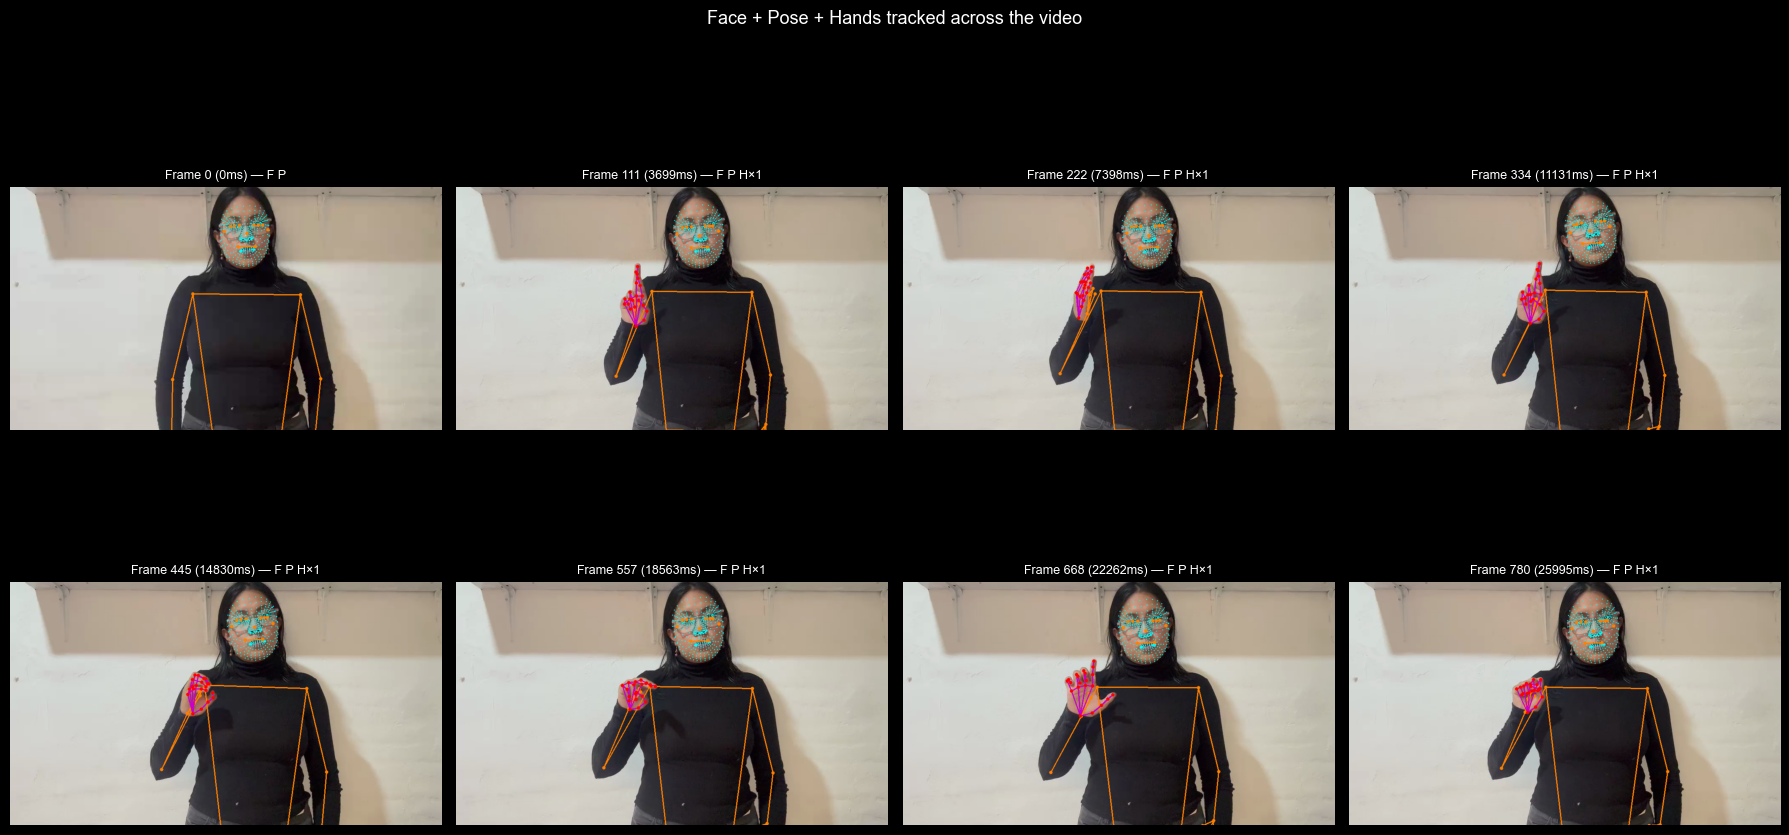

In [11]:
sample_indices = np.linspace(0, len(all_results) - 1, 8, dtype=int)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, idx in zip(axes.flat, sample_indices):
    f_idx, ts, face_r, pose_r, hand_r = all_results[idx]
    frame = all_frames[idx]
    annotated = draw_all_landmarks(frame, face_r, pose_r, hand_r)
    ax.imshow(annotated)
    tags = []
    if face_r.face_landmarks: tags.append("F")
    if pose_r.pose_landmarks: tags.append("P")
    if hand_r.hand_landmarks: tags.append(f"H×{len(hand_r.hand_landmarks)}")
    ax.set_title(f"Frame {f_idx} ({ts}ms) — {' '.join(tags) or 'none'}", fontsize=9)
    ax.axis("off")

plt.suptitle("Face + Pose + Hands tracked across the video", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Build the combined per-frame feature vector

This is the shape we'll feed into the next-gen LSM model. Following the convention from the original Holistic-based sign-language papers:

| Group | Per-point dims | Points | Subtotal |
| ----- | -------------- | ------ | -------- |
| Pose  | x, y, z, visibility | 33 | **132** |
| Face  | x, y, z             | 478 | **1434** |
| Left hand  | x, y, z       | 21 | **63** |
| Right hand | x, y, z       | 21 | **63** |
| **Total per frame** | | | **1692** |

(Classic Holistic papers used a 468-point face mesh → 1404 → total 1662. The newer `face_landmarker.task` returns 478 points, hence 1692.)

Missing detections become zeros so the vector size stays constant — downstream models can mask zeros if needed.

In [12]:
POSE_DIMS = 33 * 4   # x, y, z, visibility
FACE_DIMS = 478 * 3  # x, y, z (no visibility on face mesh)
HAND_DIMS = 21 * 3   # x, y, z, per hand
FEATURE_DIM = POSE_DIMS + FACE_DIMS + HAND_DIMS * 2


def extract_pose_vec(pose_result):
    if not pose_result.pose_landmarks:
        return np.zeros(POSE_DIMS, dtype=np.float32)
    lms = pose_result.pose_landmarks[0]
    return np.array(
        [[lm.x, lm.y, lm.z, lm.visibility] for lm in lms], dtype=np.float32
    ).flatten()


def extract_face_vec(face_result):
    if not face_result.face_landmarks:
        return np.zeros(FACE_DIMS, dtype=np.float32)
    lms = face_result.face_landmarks[0]
    return np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32).flatten()


def extract_hand_vecs(hand_result):
    """Return (left_vec, right_vec) — zeros when a hand is missing."""
    left = np.zeros(HAND_DIMS, dtype=np.float32)
    right = np.zeros(HAND_DIMS, dtype=np.float32)
    if hand_result.hand_landmarks:
        for i, lms in enumerate(hand_result.hand_landmarks):
            vec = np.array([[lm.x, lm.y, lm.z] for lm in lms], dtype=np.float32).flatten()
            label = hand_result.handedness[i][0].display_name
            if label == "Left":
                left = vec
            else:
                right = vec
    return left, right


def build_feature_vector(face_r, pose_r, hand_r):
    pose_v = extract_pose_vec(pose_r)
    face_v = extract_face_vec(face_r)
    left_v, right_v = extract_hand_vecs(hand_r)
    return np.concatenate([pose_v, face_v, left_v, right_v])


# Build the (n_frames, FEATURE_DIM) tensor for the whole video
feature_tensor = np.stack(
    [build_feature_vector(f, p, h) for _, _, f, p, h in all_results]
)

print(f"Per-frame feature dim: {FEATURE_DIM}")
print(f"  pose:       {POSE_DIMS}")
print(f"  face:       {FACE_DIMS}")
print(f"  left hand:  {HAND_DIMS}")
print(f"  right hand: {HAND_DIMS}")
print(f"\nFull-video tensor shape: {feature_tensor.shape}  (n_frames, feature_dim)")
print(f"Memory: {feature_tensor.nbytes / 1024:.1f} KB")

Per-frame feature dim: 1692
  pose:       132
  face:       1434
  left hand:  63
  right hand: 63

Full-video tensor shape: (781, 1692)  (n_frames, feature_dim)
Memory: 5161.9 KB


## 13. Notes for the LSM integration

- **Performance.** Running three landmarkers in series is slower than the legacy Holistic single-pass model. Expect ~30-50% of real-time on an M-series CPU at 720p. For the Streamlit app, run on every 2nd-3rd frame, not every frame.
- **Mode selection.** Use `RunningMode.IMAGE` for one-off images, `VIDEO` for offline clip processing (deterministic timestamps), and `LIVE_STREAM` (with a result callback) for the webrtc worker. Mixing modes inside one process is fine — each landmarker is independent.
- **Normalization.** The current project wrist-centers hand landmarks. For the combined model you'll want a unified anchor — usually the midpoint between `LEFT_SHOULDER` (pose 11) and `RIGHT_SHOULDER` (pose 12), with a scale taken from shoulder width. Apply the same transform to face and hand points so all three groups live in the same reference frame.
- **Zero-padding for missing detections.** `extract_*_vec` returns zeros when a part is undetected. For a Transformer/RNN you'll likely want either (a) a learned mask token concatenated to the feature, or (b) a binary presence channel per group — pick one strategy and stick with it across train/val/test/inference.
- **Handedness flip.** MediaPipe assumes a non-mirrored selfie view. If your training videos are mirrored (front-facing webcam), the `Left`/`Right` labels will be swapped relative to the signer's actual hands. Either flip the frame before detection or remap labels after — be consistent end-to-end.
- **Trim the face mesh.** 478 face points is overkill for sign language. The original Holistic-based sign-language papers usually keep only ~50 expression-relevant points (eyes, eyebrows, lip outline). Trimming brings the per-frame feature from 1692 → ~360 and trains much faster.
